In [61]:
import numpy as np
import pandas as  pd
import seaborn as sns
import matplotlib.pyplot as plt

# data Loading

In [62]:
data_loyality = pd.read_csv("Dataset/Customer Loyalty History.csv")

In [63]:
data_activity =pd.read_csv("Dataset/Customer Flight Activity.csv")

In [64]:
data_calender = pd.read_csv("Dataset/Calendar.csv")

In [65]:
data_loyality

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


In [66]:
data_loyality.sort_values(by=['Enrollment Year','Enrollment Month'])
# data1.reset_index(drop=True)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
152,695755,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,79088.0,Married,Star,4144.87,Standard,2012,4,NaN,NaN
294,639701,Canada,Ontario,Trenton,K8V 4B2,Female,Master,72027.0,Single,Star,4386.28,Standard,2012,4,NaN,NaN
654,565041,Canada,Quebec,Tremblant,H5Y 2S9,Male,Bachelor,98417.0,Married,Star,4881.39,Standard,2012,4,NaN,NaN
712,703882,Canada,British Columbia,Whistler,V6T 1Y8,Male,College,NaN,Single,Star,4922.17,Standard,2012,4,NaN,NaN
1516,742356,Canada,Ontario,Toronto,M2M 7K8,Female,College,NaN,Single,Aurora,5936.01,Standard,2012,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15999,975212,Canada,New Brunswick,Fredericton,E3B 2H2,Male,Bachelor,100803.0,Married,Star,13576.14,Standard,2018,12,NaN,NaN
16131,776399,Canada,Manitoba,Winnipeg,R2C 0M5,Female,High School or Below,78318.0,Married,Star,15114.40,Standard,2018,12,NaN,NaN
16267,367006,Canada,Ontario,Trenton,K8V 4B2,Male,College,NaN,Married,Star,17288.55,Standard,2018,12,NaN,NaN
16342,382971,Canada,Quebec,Montreal,H2T 2J6,Male,Bachelor,60470.0,Married,Star,19190.32,Standard,2018,12,NaN,NaN


In [67]:
data_activity

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...
392931,999986,2018,4,0,0,0.0,0,0
392932,999986,2018,5,0,0,0.0,0,0
392933,999986,2018,6,0,0,0.0,0,0
392934,999986,2018,9,0,0,0.0,0,0


# Churn Analysis

# Phase 1

In [68]:
#Agreegate Total points
customer_behavior = data_activity.groupby("Loyalty Number").agg(
    Average_distance=(" Distance", "mean"),
    Total_Bookings=(" Total Flights", "sum")
).reset_index()


In [69]:
customer_behavior

,Loyalty Number,Average_distance,Total_Bookings
0,100018,3382.916667,46
1,100102,2871.583333,51
2,100140,3035.666667,47
3,100214,1593.166667,22
4,100272,2291.541667,37
...,...,...,...
16732,999902,3488.541667,50
16733,999911,0.000000,0
16734,999940,1178.125000,18
16735,999982,346.791667,6


In [70]:
# # 3. Split the data
# recent_data = data_activity[data_activity[' Year'] == 2018]
# historical_data = data_activity[data_activity[' Year'] == 2017]

# # 4. Group by Loyalty Number
# recent_flights = recent_data.groupby('Loyalty Number')[' Total Flights'].sum().reset_index()
# historical_flights = historical_data.groupby('Loyalty Number')[' Total Flights'].sum().reset_index()

# # 5. THE BULLETPROOF RENAME: Force the exact column names
# recent_flights.columns = ['Loyalty Number', 'Recent_Bookings']
# historical_flights.columns = ['Loyalty Number', 'Historical_Bookings']

# # 6. Merge them together
# customer_behavior = customer_behavior.merge(recent_flights, on='Loyalty Number', how='left')
# customer_behavior = customer_behavior.merge(historical_flights, on='Loyalty Number', how='left')

# # 7. Fill missing values and calculate velocity
# customer_behavior['Recent_Bookings'] = customer_behavior['Recent_Bookings'].fillna(0)
# customer_behavior['Historical_Bookings'] = customer_behavior['Historical_Bookings'].fillna(0)
# customer_behavior['Booking_Velocity'] = customer_behavior['Recent_Bookings'] / (customer_behavior['Historical_Bookings'] + 1)

# # Display the final, fixed data




In [71]:
data_loyality['Customer_Age_Months'] = (
    (2018 - data_loyality['Enrollment Year'])*12
    + (12 - data_loyality['Enrollment Month'])
)
data_loyality['Customer_Age_Status'] = data_loyality['Customer_Age_Months'].apply(lambda x: 'New' if x <= 6 else 'Old' if x <= 24 else 'very old')

In [72]:
# Recent period: Jul-Dec 2018
recent_data = data_activity[
    (data_activity[' Year'] == 2018) &
    (data_activity[' Month'] >= 7)
]

# Historical period: Jan 2017 - Jun 2018
historical_data = data_activity[
    ((data_activity[' Year'] == 2017)) |
    ((data_activity[' Year'] == 2018) & (data_activity[' Month'] <= 6))
]

In [73]:
# ==========================
# BOOKING TREND FEATURE
# ==========================

# Recent period: Jul-Dec 2018 (6 months)
recent_bookings = (
    recent_data
    .groupby('Loyalty Number')[' Total Flights']
    .sum()
)

# Historical period: Jan 2017 - Jun 2018
historical_bookings = (
    historical_data
    .groupby('Loyalty Number')[' Total Flights']
    .sum()
)

# Combine both
booking_trend = pd.concat(
    [recent_bookings, historical_bookings],
    axis=1
).fillna(0)

booking_trend.columns = [
    'Recent_Bookings',
    'Historical_Bookings'
]

# Convert index back to column
booking_trend = booking_trend.reset_index()

# Merge customer age
booking_trend = booking_trend.merge(
    data_loyality[['Loyalty Number', 'Customer_Age_Months']],
    on='Loyalty Number',
    how='left'
)

# --------------------------
# Historical Months
# --------------------------

# Maximum observation window = 24 months
# Recent period already occupies last 6 months

booking_trend['Historical_Months'] = (
    booking_trend['Customer_Age_Months']
    .clip(upper=24)
    - 6
)

# Avoid divide-by-zero for very new customers
booking_trend['Historical_Months'] = (
    booking_trend['Historical_Months']
    .clip(lower=1)
)

# --------------------------
# Monthly Booking Rates
# --------------------------

booking_trend['Recent_Booking_Rate'] = (
    booking_trend['Recent_Bookings'] / 6
)

booking_trend['Historical_Booking_Rate'] = (
    booking_trend['Historical_Bookings']
    /
    booking_trend['Historical_Months']
)

# --------------------------
# Booking Trend
# --------------------------

# Positive = booking more recently
# Negative = booking less recently

booking_trend['Booking_Trend'] = (
    booking_trend['Recent_Booking_Rate']
    -
    booking_trend['Historical_Booking_Rate']
)

# Keep only required columns
booking_trend = booking_trend[
    [
        'Loyalty Number',
        'Recent_Bookings',
        'Historical_Bookings',
        'Recent_Booking_Rate',
        'Historical_Booking_Rate',
        'Booking_Trend'
    ]
]

# Merge into customer table
customer_behavior = customer_behavior.merge(
    booking_trend[
        ['Loyalty Number', 'Booking_Trend']
    ],
    on='Loyalty Number',
    how='left'
)

customer_behavior['Booking_Trend'] = (
    customer_behavior['Booking_Trend']
    .fillna(0)
)

print(customer_behavior[['Loyalty Number','Booking_Trend']].head())

   Loyalty Number  Booking_Trend
0          100018       1.222222
1          100102       0.944444
2          100140      -0.166667
3          100214       0.777778
4          100272      -0.055556


In [74]:
customer_behavior

,Loyalty Number,Average_distance,Total_Bookings,Booking_Trend
0,100018,3382.916667,46,1.222222
1,100102,2871.583333,51,0.944444
2,100140,3035.666667,47,-0.166667
3,100214,1593.166667,22,0.777778
4,100272,2291.541667,37,-0.055556
...,...,...,...,...
16732,999902,3488.541667,50,-1.444444
16733,999911,0.000000,0,0.000000
16734,999940,1178.125000,18,1.196970
16735,999982,346.791667,6,1.000000


In [75]:
# if Points_Velocity == 0,1 then this userburns points fast 
# else this user burns points slowly
#Recent_bookings = booking in last 6 months
# historical booking = booking in previous 18 months
#recent_booking_rate = recent_bookings / 6
#historical_booking_rate = historical_bookings / 18
#booking_trend = recent_booking_rate / (historical_booking_rate + 1e-6)

In [76]:
# ==========================
# ACCUMULATION TREND FEATURE
# ==========================

# Recent accumulation (Jul-Dec 2018)
recent_acc = (
    recent_data
    .groupby('Loyalty Number')[' Points Accumulated']
    .sum()
)

# Historical accumulation (Jan 2017-Jun 2018)
historical_acc = (
    historical_data
    .groupby('Loyalty Number')[' Points Accumulated']
    .sum()
)

# Combine
acc_trend = pd.concat(
    [recent_acc, historical_acc],
    axis=1
).fillna(0)

acc_trend.columns = [
    'Recent_Accumulation',
    'Historical_Accumulation'
]

# Index → Column
acc_trend = acc_trend.reset_index()

# Merge customer age
acc_trend = acc_trend.merge(
    data_loyality[['Loyalty Number', 'Customer_Age_Months']],
    on='Loyalty Number',
    how='left'
)

# --------------------------
# Historical Months
# --------------------------

acc_trend['Historical_Months'] = (
    acc_trend['Customer_Age_Months']
    .clip(upper=24)
    - 6
)

acc_trend['Historical_Months'] = (
    acc_trend['Historical_Months']
    .clip(lower=1)
)

# --------------------------
# Monthly Rates
# --------------------------

acc_trend['Recent_Acc_Rate'] = (
    acc_trend['Recent_Accumulation'] / 6
)

acc_trend['Historical_Acc_Rate'] = (
    acc_trend['Historical_Accumulation']
    /
    acc_trend['Historical_Months']
)

# --------------------------
# Trend
# --------------------------

acc_trend['Accumulation_Trend'] = (
    acc_trend['Recent_Acc_Rate']
    -
    acc_trend['Historical_Acc_Rate']
)

# Keep required columns
acc_trend = acc_trend[
    [
        'Loyalty Number',
        'Recent_Accumulation',
        'Historical_Accumulation',
        'Recent_Acc_Rate',
        'Historical_Acc_Rate',
        'Accumulation_Trend'
    ]
]

# Merge into customer table
customer_behavior = customer_behavior.merge(
    acc_trend[
        ['Loyalty Number', 'Accumulation_Trend']
    ],
    on='Loyalty Number',
    how='left'
)

customer_behavior['Accumulation_Trend'] = (
    customer_behavior['Accumulation_Trend']
    .fillna(0)
)

print(
    customer_behavior[
        ['Loyalty Number','Accumulation_Trend']
    ].head()
)

   Loyalty Number  Accumulation_Trend
0          100018         3573.222222
1          100102          347.888889
2          100140          505.333333
3          100214         1058.222222
4          100272          591.722222


In [77]:
# ==========================
# REDEMPTION TREND FEATURE
# ==========================

# Recent redemption (Jul-Dec 2018)
recent_red = (
    recent_data
    .groupby('Loyalty Number')[' Points Redeemed']
    .sum()
)

# Historical redemption (Jan 2017-Jun 2018)
historical_red = (
    historical_data
    .groupby('Loyalty Number')[' Points Redeemed']
    .sum()
)

# Combine
red_trend = pd.concat(
    [recent_red, historical_red],
    axis=1
).fillna(0)

red_trend.columns = [
    'Recent_Redemption',
    'Historical_Redemption'
]

# Index → Column
red_trend = red_trend.reset_index()

# Merge customer age
red_trend = red_trend.merge(
    data_loyality[['Loyalty Number', 'Customer_Age_Months']],
    on='Loyalty Number',
    how='left'
)

# --------------------------
# Historical Months
# --------------------------

red_trend['Historical_Months'] = (
    red_trend['Customer_Age_Months']
    .clip(upper=24)
    - 6
)

red_trend['Historical_Months'] = (
    red_trend['Historical_Months']
    .clip(lower=1)
)

# --------------------------
# Monthly Rates
# --------------------------

red_trend['Recent_Red_Rate'] = (
    red_trend['Recent_Redemption'] / 6
)

red_trend['Historical_Red_Rate'] = (
    red_trend['Historical_Redemption']
    /
    red_trend['Historical_Months']
)

# --------------------------
# Trend
# --------------------------

red_trend['Redemption_Trend'] = (
    red_trend['Recent_Red_Rate']
    -
    red_trend['Historical_Red_Rate']
)

# Keep required columns
red_trend = red_trend[
    [
        'Loyalty Number',
        'Recent_Redemption',
        'Historical_Redemption',
        'Recent_Red_Rate',
        'Historical_Red_Rate',
        'Redemption_Trend'
    ]
]

# Merge into customer table
customer_behavior = customer_behavior.merge(
    red_trend[
        ['Loyalty Number', 'Redemption_Trend']
    ],
    on='Loyalty Number',
    how='left'
)

customer_behavior['Redemption_Trend'] = (
    customer_behavior['Redemption_Trend']
    .fillna(0)
)

print(
    customer_behavior[
        ['Loyalty Number','Redemption_Trend']
    ].head()
)

   Loyalty Number  Redemption_Trend
0          100018          1.500000
1          100102        -66.388889
2          100140        -32.944444
3          100214        -47.833333
4          100272        -55.944444


In [78]:
# customer_behavior.drop(['Recent_Accumulation','Historical_Accumulation','Recent_Redeemed','Historical_Redeemed','Recent_Bookings','Historical_Bookings'], axis=1, inplace=True)


In [79]:
customer_behavior

,Loyalty Number,Average_distance,Total_Bookings,Booking_Trend,Accumulation_Trend,Redemption_Trend
0,100018,3382.916667,46,1.222222,3573.222222,1.500000
1,100102,2871.583333,51,0.944444,347.888889,-66.388889
2,100140,3035.666667,47,-0.166667,505.333333,-32.944444
3,100214,1593.166667,22,0.777778,1058.222222,-47.833333
4,100272,2291.541667,37,-0.055556,591.722222,-55.944444
...,...,...,...,...,...,...
16732,999902,3488.541667,50,-1.444444,-2431.388889,-48.666667
16733,999911,0.000000,0,0.000000,0.000000,0.000000
16734,999940,1178.125000,18,1.196970,1819.666667,112.000000
16735,999982,346.791667,6,1.000000,1387.166667,0.000000


# Phase 2

In [80]:
season_map = {
    12: "Winter" ,
    1: "Winter" ,
    2: "Winter" ,
    3: "Spring" ,
    4: "Spring" ,
    5: "Spring" ,
    6: "Summer" ,
    7: "Summer" ,
    8: "Summer" ,
    9: "Autumn" ,
    10: "Autumn" ,
    11: "Autumn" ,
}

data_activity['Season'] = data_activity[' Month'].map(season_map)

seasonal_profile =data_activity.groupby(['Loyalty Number', 'Season'])[" Total Flights"].sum().unstack(fill_value=0)

# Rename the columns to match the project requirements cleanly
seasonal_profile.columns = [f'Bookings_{season}' for season in seasonal_profile.columns]

# 3. Derive a Seasonality Index (Variance)
# Calculate the statistical variance across the 4 seasonal columns for each user
seasonal_columns = ['Bookings_Winter', 'Bookings_Spring', 'Bookings_Summer', 'Bookings_Autumn']
seasonal_profile['Seasonality_Index'] = seasonal_profile[seasonal_columns].var(axis=1)

# Round the index for cleaner output
seasonal_profile['Seasonality_Index'] = seasonal_profile['Seasonality_Index'].round(2)

# 4. The Master Merge
# Attach these 5 new columns to our existing Phase 1 customer_behavior table
customer_behavior = customer_behavior.merge(seasonal_profile[['Seasonality_Index']], on='Loyalty Number', how='left')

In [81]:
# low seasonality_index means more consistent booking behavior across seasons
#and high seaonality_index means very inconsistent in booking flights through seasons

In [82]:
seasonal_profile

,Bookings_Autumn,Bookings_Spring,Bookings_Summer,Bookings_Winter,Seasonality_Index
Loyalty Number,,,,,
100018,18,8,10,10,19.67
100102,16,13,10,12,6.25
100140,13,13,11,10,2.25
100214,9,1,4,8,13.67
100272,5,11,16,5,28.25
...,...,...,...,...,...
999902,9,11,21,9,33.00
999911,0,0,0,0,0.00
999940,8,0,4,6,11.67


In [83]:
# for recent flights 
flight_df = data_activity[data_activity[" Total Flights"] > 0]

last_flight = (
    flight_df.sort_values(['Loyalty Number', ' Year',' Month'])
    .groupby('Loyalty Number')
    .tail(1)[['Loyalty Number', ' Year', ' Month']]
)

In [84]:
reference_year = 2018
reference_month = 12

last_flight["Recency_Months"] = (
    (reference_year - last_flight[' Year']) * 12 + (reference_month - last_flight[' Month'])
)

In [85]:
customer_behavior = customer_behavior.merge(last_flight[
    ['Loyalty Number', 'Recency_Months']
], on='Loyalty Number', how='left')

In [86]:
customer_behavior

,Loyalty Number,Average_distance,Total_Bookings,Booking_Trend,Accumulation_Trend,Redemption_Trend,Seasonality_Index,Recency_Months
0,100018,3382.916667,46,1.222222,3573.222222,1.500000,19.67,0.0
1,100102,2871.583333,51,0.944444,347.888889,-66.388889,6.25,0.0
2,100140,3035.666667,47,-0.166667,505.333333,-32.944444,2.25,1.0
3,100214,1593.166667,22,0.777778,1058.222222,-47.833333,13.67,0.0
4,100272,2291.541667,37,-0.055556,591.722222,-55.944444,28.25,1.0
...,...,...,...,...,...,...,...,...
16732,999902,3488.541667,50,-1.444444,-2431.388889,-48.666667,33.00,2.0
16733,999911,0.000000,0,0.000000,0.000000,0.000000,0.00,NaN
16734,999940,1178.125000,18,1.196970,1819.666667,112.000000,11.67,0.0
16735,999982,346.791667,6,1.000000,1387.166667,0.000000,3.67,1.0


In [87]:
print(customer_behavior['Recency_Months'].describe())
print(customer_behavior['Booking_Trend'].describe())
print(customer_behavior['Accumulation_Trend'].describe())

count    15167.000000
mean         1.446298
std          3.508961
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         23.000000
Name: Recency_Months, dtype: float64
count    16737.000000
mean        -0.341102
std          3.623032
min        -50.000000
25%         -0.500000
50%          0.000000
75%          0.666667
max         10.833333
Name: Booking_Trend, dtype: float64
count    16737.000000
mean      -558.290570
std       6052.187656
min     -81267.833333
25%       -842.222222
50%          0.000000
75%       1104.666667
max      33355.250000
Name: Accumulation_Trend, dtype: float64


In [89]:
customer_behavior['Recency_Months'].quantile([0.75,0.90,0.95])

0.75    1.0
0.90    3.0
0.95    7.0
Name: Recency_Months, dtype: float64

In [90]:
booking_cutoff = customer_behavior['Booking_Trend'].quantile(0.25)
acc_cutoff = customer_behavior['Accumulation_Trend'].quantile(0.25)
recency_cutoff = customer_behavior['Recency_Months'].quantile(0.90)

customer_behavior['Behavioral_Churn'] = (
    (customer_behavior['Recency_Months'] >= recency_cutoff) &
    (customer_behavior['Booking_Trend'] <= booking_cutoff) &
    (customer_behavior['Accumulation_Trend'] <= acc_cutoff)
).astype(int)

In [ ]:
customer_behavior['Behavioral_Churn'].value_counts()


Behavioral_Churn
0    16122
1      615
Name: count, dtype: int64

In [91]:
customer_behavior['Behavioral_Churn'].value_counts(normalize=True) * 100

Behavioral_Churn
0    93.493458
1     6.506542
Name: proportion, dtype: float64

In [94]:
customer_behavior[
    customer_behavior['Behavioral_Churn'] == 1
][[
    'Recency_Months',
    'Booking_Trend',
    'Accumulation_Trend',
    'Total_Bookings'
]].describe()

,Recency_Months,Booking_Trend,Accumulation_Trend,Total_Bookings
count,1089.000000,1089.000000,1089.000000,1089.000000
mean,8.104683,-1.984262,-3329.222385,24.507805
std,4.922568,4.077293,6927.173009,11.864360
min,3.000000,-41.833333,-70269.666667,2.000000
25%,4.000000,-1.500000,-2362.500000,15.000000
50%,6.000000,-1.166667,-1754.000000,22.000000
75%,12.000000,-0.888889,-1309.000000,33.000000
max,21.000000,-0.500000,-843.944444,72.000000


In [ ]:
hello = customer_behavior['Behavioral_Churn'] > 0
hello.sum()

np.int64(7154)

Merger

In [96]:
data_main = data_loyality.merge(customer_behavior, on='Loyalty Number', how='left')

In [97]:
data_main['Salary'] = pd.to_numeric(data_main['Salary'], errors='coerce')
data_main['Salary'] = data_main['Salary'].abs()

In [98]:
data_main["Hard_Churn"] = data_main["Cancellation Year"].notna().astype(int)

In [99]:
pd.crosstab(
    data_main['Behavioral_Churn'],
    data_main['Hard_Churn'],
    margins=True
)

Hard_Churn,0,1,All
Behavioral_Churn,,,
0,14200,1448,15648
1,470,619,1089
All,14670,2067,16737


In [100]:
pd.crosstab(
    data_main['Behavioral_Churn'],
    data_main['Hard_Churn'],
    normalize='index'
) * 100

Hard_Churn,0,1
Behavioral_Churn,,
0,90.746421,9.253579
1,43.158861,56.841139


In [ ]:
data_main

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Customer_Age_Status,Average_distance,Total_Bookings,Booking_Trend,Accumulation_Trend,Redemption_Trend,Seasonality_Index,Recency_Months,Behavioral_Churn,Hard_Churn
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,Old,2271.875000,37,0.357143,1.26,8.72,28.92,0.0,0,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,...,Old,3228.625000,58,-0.095238,0.13,1.17,17.00,0.0,0,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,...,Old,1033.458333,18,-0.500000,-1.00,-0.95,1.67,11.0,1,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,...,Old,2018.000000,35,-0.312500,-0.55,0.47,2.92,0.0,0,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,...,Old,2313.125000,37,0.815789,0.85,0.00,22.25,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,...,Old,2220.541667,38,0.536585,1.28,0.00,25.00,0.0,0,0
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,...,Old,3586.333333,59,0.527273,1.34,7.38,4.92,0.0,0,0
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,...,Old,2566.458333,50,-0.035714,-0.26,0.54,35.00,0.0,0,0
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,57297.0,Married,Star,...,Old,6258.454545,51,3.258065,8.25,0.00,112.92,0.0,0,0


In [ ]:
data_main.isna().sum()

Loyalty Number             0
Country                    0
Province                   0
City                       0
Postal Code                0
Gender                     0
Education                  0
Salary                  4238
Marital Status             0
Loyalty Card               0
CLV                        0
Enrollment Type            0
Enrollment Year            0
Enrollment Month           0
Cancellation Year      14670
Cancellation Month     14670
Customer_Age_Months        0
Customer_Age_Status        0
Average_distance           0
Total_Bookings             0
Booking_Trend              0
Accumulation_Trend         0
Redemption_Trend           0
Seasonality_Index          0
Recency_Months          1570
Behavioral_Churn           0
Hard_Churn                 0
dtype: int64

In [101]:
data_main['Salary'] = data_main['Salary'].fillna(0)
data_main['Cancellation Year'] = data_main['Cancellation Year'].fillna(0)
data_main['Cancellation Month'] = data_main['Cancellation Month'].fillna(0)

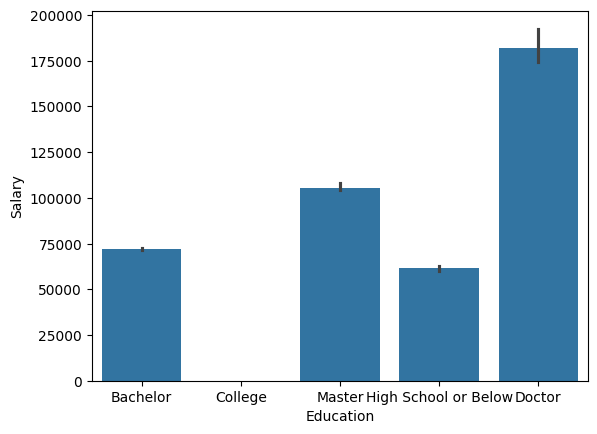

<Figure size 1600x800 with 0 Axes>

In [102]:
ax = sns.barplot(data=data_loyality, x="Education", y="Salary", estimator=np.median)
plt.figure(figsize=(16, 8))
plt.show()

In [103]:
# Count missing salaries grouped by Education
missing_by_edu = data_loyality[data_loyality['Salary'].isna()]['Education'].value_counts()

print("Missing Salaries per Education Level:")
print(missing_by_edu)

Missing Salaries per Education Level:
Education
College    4238
Name: count, dtype: int64


In [104]:
# Count missing salaries grouped by Education
missing_by_edu = data_loyality[data_loyality['Cancellation Year'].isna()]['Province'].value_counts()

print("Missing Cancellation Year per Education Level:")
print(missing_by_edu)

Missing Cancellation Year per Education Level:
Province
Ontario                 4730
British Columbia        3887
Quebec                  2887
Alberta                  847
New Brunswick            569
Manitoba                 558
Nova Scotia              460
Saskatchewan             359
Newfoundland             220
Yukon                     98
Prince Edward Island      55
Name: count, dtype: int64


# Phase 4

<Axes: xlabel='Total_Bookings', ylabel='CLV'>

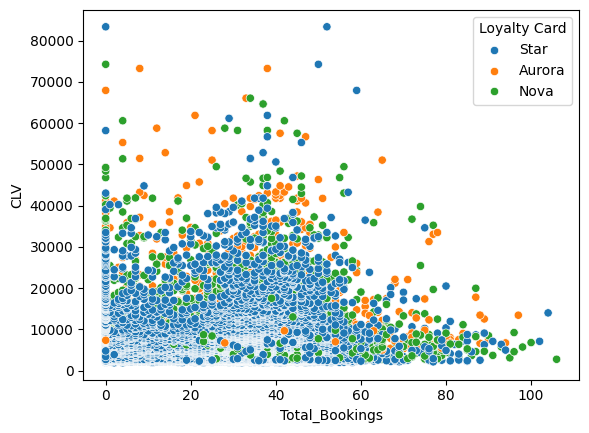

In [105]:
sns.scatterplot(data=data_main, x="Total_Bookings", y="CLV", hue="Loyalty Card")

In [ ]:
customer_behavior

,Loyalty Number,Average_distance,Total_Bookings,Booking_Trend,Accumulation_Trend,Redemption_Trend,Seasonality_Index,Recency_Months,Behavioral_Churn
0,100018,3382.916667,46,0.468085,1.43,0.02,19.67,0.0,0
1,100102,2871.583333,51,0.326923,0.12,-0.99,6.25,0.0,0
2,100140,3035.666667,47,-0.055556,0.17,-0.97,2.25,1.0,1
3,100214,1593.166667,22,0.451613,0.80,-0.98,13.67,0.0,0
4,100272,2291.541667,37,-0.021739,0.28,-0.98,28.25,1.0,1
...,...,...,...,...,...,...,...,...,...
16732,999902,3488.541667,50,-0.419355,-0.59,-0.98,33.00,2.0,1
16733,999911,0.000000,0,0.000000,0.00,0.00,0.00,NaN,1
16734,999940,1178.125000,18,1.040000,3.55,112.00,11.67,0.0,0
16735,999982,346.791667,6,1.000000,1387.17,0.00,3.67,1.0,0


In [106]:
selected_features = ['Salary','CLV','Accumulation_Trend' , 'Redemption_Trend','Recency_Months','Hard_Churn']

corr_matrix = data_main[selected_features].corr()

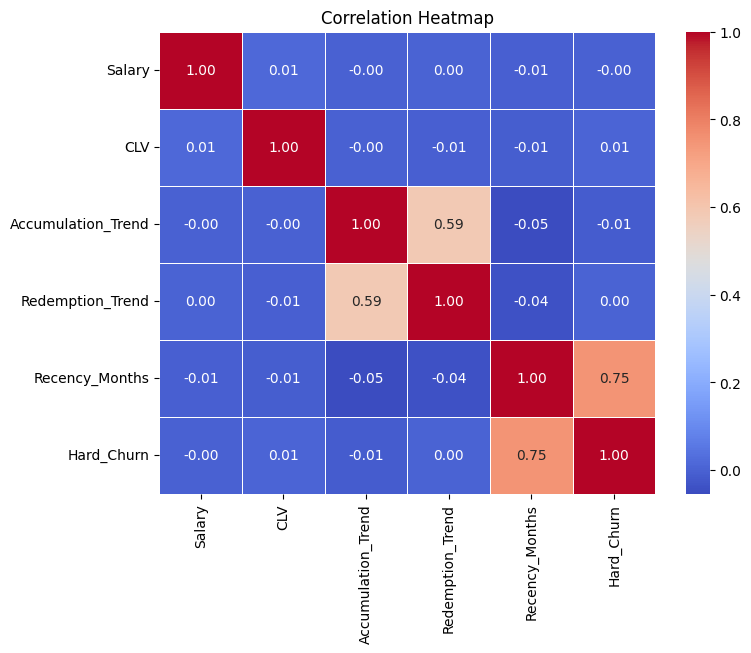

In [107]:
# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,      # Show correlation values
    cmap='coolwarm', # Color scheme
    fmt='.2f',       # 2 decimal places
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='Hard_Churn', ylabel='Recency_Months'>

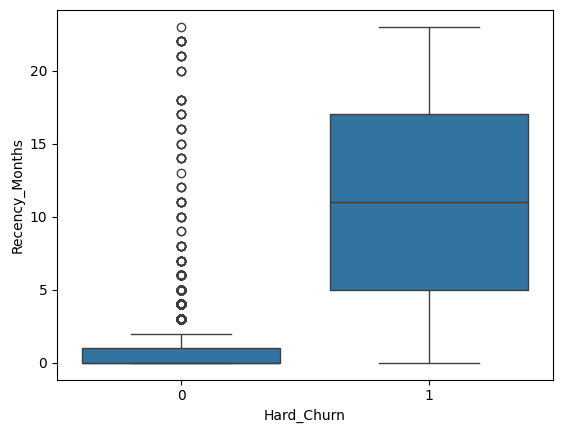

In [108]:
sns.boxplot(data=data_main, x='Hard_Churn',y='Recency_Months')

<Axes: xlabel='Recency_Months', ylabel='Count'>

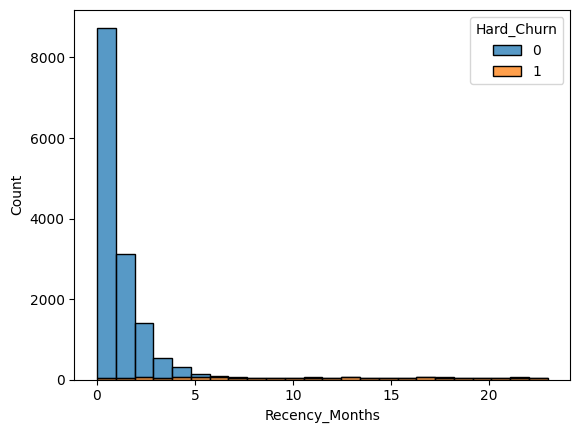

In [109]:
sns.histplot(
    data=data_main,
    x='Recency_Months',
    hue='Hard_Churn',
    bins=24,
    multiple='stack'
)

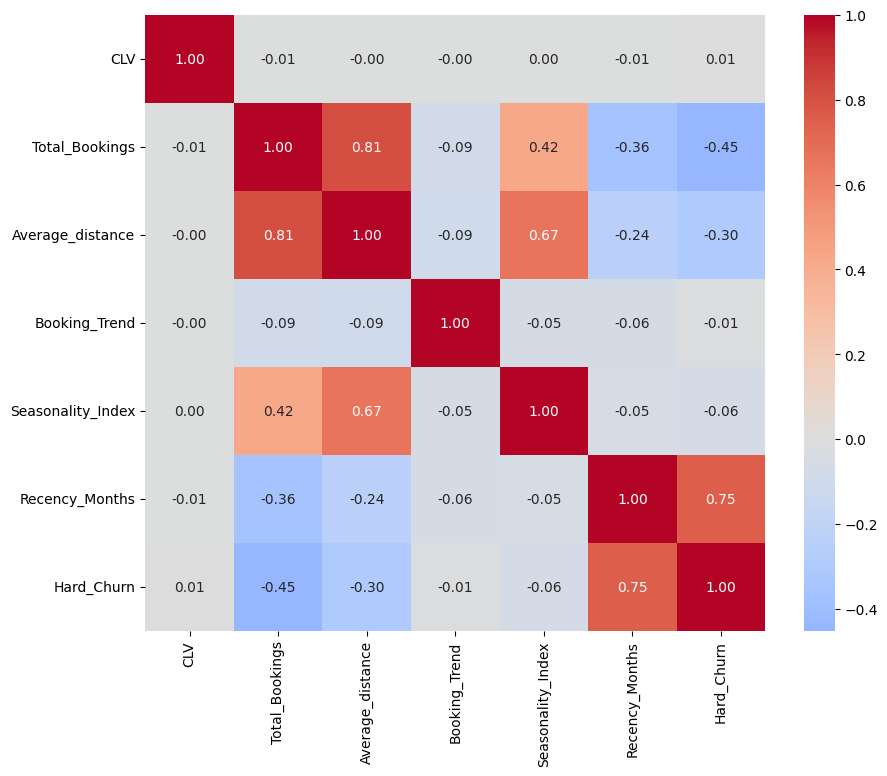

In [110]:
features = [
    'CLV',
    'Total_Bookings',
    'Average_distance',
    'Booking_Trend',
    'Seasonality_Index',
    'Recency_Months',
    'Hard_Churn'
]

corr = data_main[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.show()

In [111]:
pd.crosstab(
    data_main['Loyalty Card'],
    data_main['Hard_Churn'],
    normalize='index'
)

Hard_Churn,0,1
Loyalty Card,,
Aurora,0.869058,0.130942
Nova,0.873567,0.126433
Star,0.882022,0.117978


# Customer Segmentation

# Pareto Analysis

In [ ]:
pareto_df = data_main.sort_values(by='CLV' , ascending=False).reset_index(drop=True)

pareto_df['Cumulative'] = pareto_df['CLV'].cumsum()
pareto_df['Cumulative_CLV_percentage'] = (pareto_df['Cumulative'] / pareto_df['CLV'].sum()) 
pareto_df["Customer_Pct"] = (pareto_df.index + 1) / len(pareto_df) 

top_60_clv_share = pareto_df[pareto_df['Customer_Pct'] <= 0.20]['Cumulative_CLV_percentage'].max()

print(f"The Top 45% of your customers account for {top_60_clv_share * 100:.1f}% of total CLV.")

The Top 45% of your customers account for 46.3% of total CLV.


# RFM Segmentation


In [ ]:
# F_score = how frequent customer flies as low score means less frequent and high means high frequent
data_main["F_score"] = pd.qcut(data_main["Total_Bookings"], q=4, labels=[1,2,3,4])
# M_score = how much money customer spends as low score means less spending and high means high spending
data_main['M_score'] = pd.qcut(data_main['CLV'], q=4, labels=[1,2,3,4])
# R_Score = how recent the customer has flown as low score means less recent and high means most recent
data_main['R_score'] = pd.qcut(data_main['Recency_Months'], q=4, labels=[2,1], duplicates='drop')

#combine both for getting vip customers
Champions = data_main[(data_main['F_score'] == 4) & (data_main['M_score'] == 4) & (data_main['R_score'] == 2)]
Loyal_Customers = data_main[(data_main['F_score'] == 4) & (data_main['M_score'] == 2) & (data_main['R_score'] == 2)]
Big_Spenders = data_main[(data_main['F_score'] == 2) & (data_main['M_score'] == 4) & (data_main['R_score'] == 2)]
Lost_Customers = data_main[(data_main['F_score'] == 1) & (data_main['M_score'] == 1) & (data_main['R_score'] == 1)]

print(f"Total VIP Customers identified: {len(Champions)}")
print(f"Total Loyal Customers identified: {len(Loyal_Customers)}")
print(f"Total Big Spenders identified: {len(Big_Spenders)}")
print(f"Total Lost Customers identified: {len(Lost_Customers)}")


Total VIP Customers identified: 907
Total Loyal Customers identified: 834
Total Big Spenders identified: 810
Total Lost Customers identified: 270


# segmentation

In [ ]:
segmentation_features = [
    'CLV',
    'Total_Bookings',
    'Average_distance',
    'Recency_Months',
    'Booking_Trend',
    'Accumulation_Trend',
    'Redemption_Trend',
    'Seasonality_Index'
]

X = data_main[segmentation_features]

In [ ]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

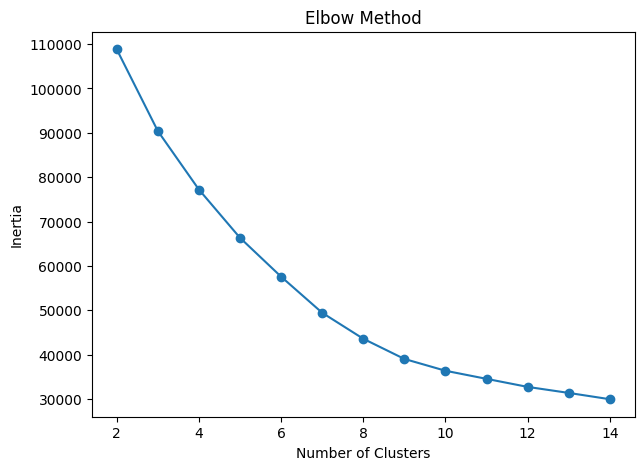

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,15):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,15), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,15):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.644
k=3, silhouette=0.351
k=4, silhouette=0.373
k=5, silhouette=0.388
k=6, silhouette=0.386
k=7, silhouette=0.404
k=8, silhouette=0.404
k=9, silhouette=0.411
k=10, silhouette=0.262
k=11, silhouette=0.268
k=12, silhouette=0.273
k=13, silhouette=0.267


KeyboardInterrupt: 

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

data_main['Segment'] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_profile = (
    data_main
    .groupby('Segment')[segmentation_features]
    .mean()
    .round(2)
)
cluster_profile

,CLV,Total_Bookings,Average_distance,Recency_Months,Booking_Trend,Accumulation_Trend,Redemption_Trend,Seasonality_Index
Segment,,,,,,,,
0,8205.21,7.31,460.24,0.80,0.55,515.74,19.43,4.95
1,8156.69,56.92,7774.54,0.68,3.08,717.45,37.16,236.64
2,7929.84,38.11,2432.31,0.71,0.13,0.36,9.25,22.31
3,7635.06,12.68,782.38,15.17,-0.38,-1.00,-0.44,9.12


In [ ]:
cluster_size = (
    data_main
    .groupby('Segment')
    .size()
    .reset_index(name='Customers')
)

print(cluster_size)


   Segment  Customers
0        0       3919
1        1        585
2        2      11475
3        3        758


In [ ]:
pd.crosstab(
    data_main['Segment'],
    data_main['Loyalty Card'],
    normalize='index'
)*100

Loyalty Card,Aurora,Nova,Star
Segment,,,
0,20.949222,33.886195,45.164583
1,21.025641,35.555556,43.418803
2,20.366013,33.559913,46.074074
3,19.525066,37.467018,43.007916


In [ ]:
pd.crosstab(
    data_main['Segment'],
    data_main['Gender'],
    normalize='index'
)*100

Gender,Female,Male
Segment,,
0,51.084460,48.915540
1,51.111111,48.888889
2,49.969499,50.030501
3,49.472296,50.527704


In [ ]:
pd.crosstab(
    data_main['Segment'],
    data_main['Education'],
    normalize='index'
)*100

Education,Bachelor,College,Doctor,High School or Below,Master
Segment,,,,,
0,63.511100,24.623628,4.337841,4.567492,2.959939
1,65.811966,23.931624,3.247863,5.299145,1.709402
2,62.222222,25.551198,4.461874,4.671024,3.093682
3,60.817942,26.517150,4.353562,4.749340,3.562005


In [ ]:
pd.crosstab(
    data_main['Segment'],
    data_main['Marital Status'],
    normalize='index'
)*100

Marital Status,Divorced,Married,Single
Segment,,,
0,15.514162,58.280174,26.205665
1,14.188034,59.316239,26.495726
2,14.962963,58.196078,26.840959
3,14.511873,56.200528,29.287599


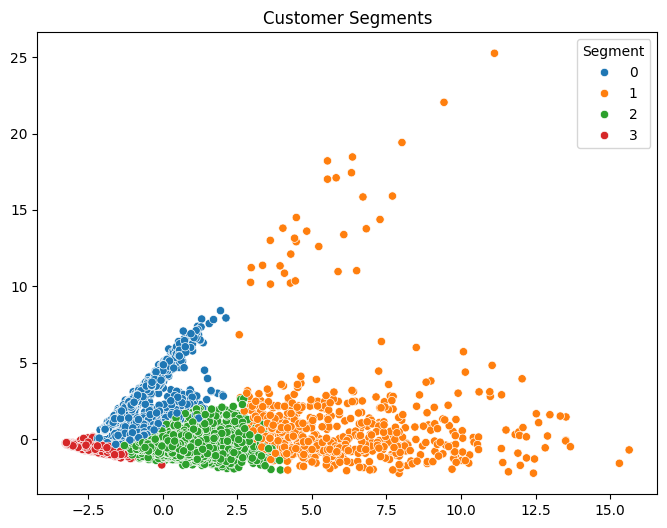

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=data_main['Segment'],
    palette='tab10'
)

plt.title('Customer Segments')
plt.show()

In [ ]:
segment_names = {
    0: 'Occasional Flyers',
    1: 'Champions / Premium Travelers',
    2: 'Active Regular Customers',
    3: 'Dormant Customers'
}

data_main['Customer_Segment'] = (
    data_main['Segment']
    .map(segment_names)
)

In [ ]:
segment_summary = (
    data_main['Customer_Segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    'Customer Segment',
    'Customers'
]

print(segment_summary)

                Customer Segment  Customers
0       Active Regular Customers      11475
1              Occasional Flyers       3919
2              Dormant Customers        758
3  Champions / Premium Travelers        585


In [ ]:
loyalty_profile = pd.crosstab(
    data_main['Customer_Segment'],
    data_main['Loyalty Card'],
    normalize='index'
)*100

print(loyalty_profile.round(2))

Loyalty Card                   Aurora   Nova   Star
Customer_Segment                                   
Active Regular Customers        20.37  33.56  46.07
Champions / Premium Travelers   21.03  35.56  43.42
Dormant Customers               19.53  37.47  43.01
Occasional Flyers               20.95  33.89  45.16


In [ ]:
gender_profile = pd.crosstab(
    data_main['Customer_Segment'],
    data_main['Gender'],
    normalize='index'
)*100

print(gender_profile.round(2))

Gender                         Female   Male
Customer_Segment                            
Active Regular Customers        49.97  50.03
Champions / Premium Travelers   51.11  48.89
Dormant Customers               49.47  50.53
Occasional Flyers               51.08  48.92


In [ ]:
education_profile = pd.crosstab(
    data_main['Customer_Segment'],
    data_main['Education'],
    normalize='index'
)*100

print(education_profile.round(2))

Education                      Bachelor  College  Doctor  \
Customer_Segment                                           
Active Regular Customers          62.22    25.55    4.46   
Champions / Premium Travelers     65.81    23.93    3.25   
Dormant Customers                 60.82    26.52    4.35   
Occasional Flyers                 63.51    24.62    4.34   

Education                      High School or Below  Master  
Customer_Segment                                             
Active Regular Customers                       4.67    3.09  
Champions / Premium Travelers                  5.30    1.71  
Dormant Customers                              4.75    3.56  
Occasional Flyers                              4.57    2.96  


In [ ]:
marital_profile = pd.crosstab(
    data_main['Customer_Segment'],
    data_main['Marital Status'],
    normalize='index'
)*100

print(marital_profile.round(2))

Marital Status                 Divorced  Married  Single
Customer_Segment                                        
Active Regular Customers          14.96    58.20   26.84
Champions / Premium Travelers     14.19    59.32   26.50
Dormant Customers                 14.51    56.20   29.29
Occasional Flyers                 15.51    58.28   26.21


In [ ]:
segment_behavior = (
    data_main
    .groupby('Customer_Segment')[segmentation_features]
    .mean()
)

In [ ]:
overall_mean = data_main[segmentation_features].mean()

relative_profile = (
    segment_behavior / overall_mean
).round(2)

In [ ]:
relative_profile.to_csv(
    "relative_segment_profile.csv"
)

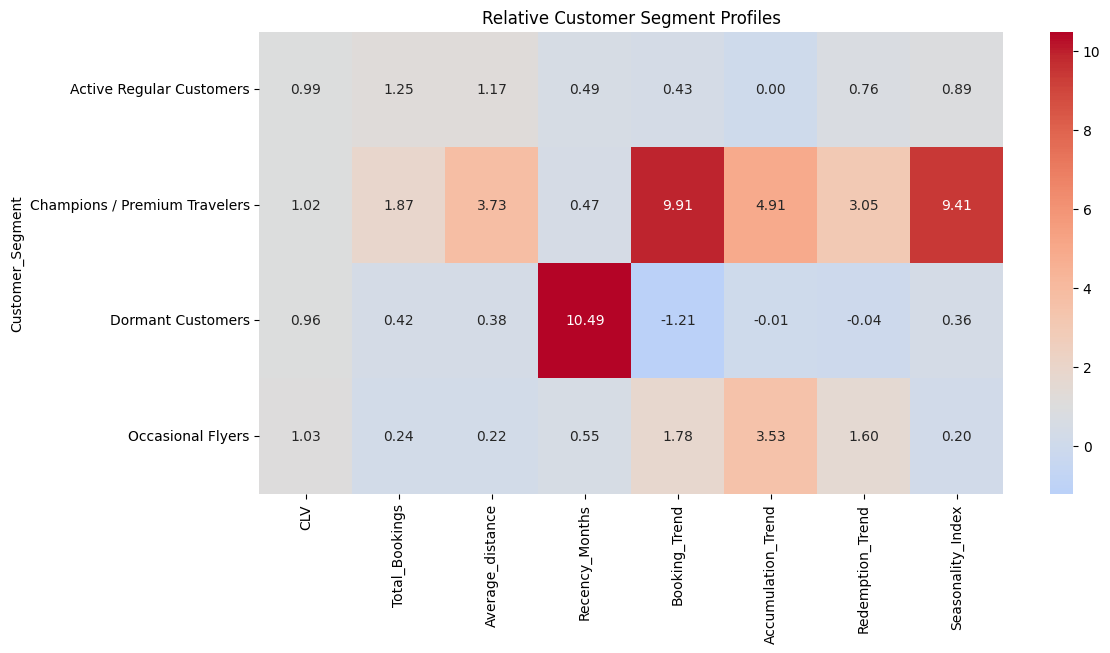

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    relative_profile,
    annot=True,
    cmap='coolwarm',
    center=1,
    fmt='.2f'
)

plt.title('Relative Customer Segment Profiles')
plt.show()

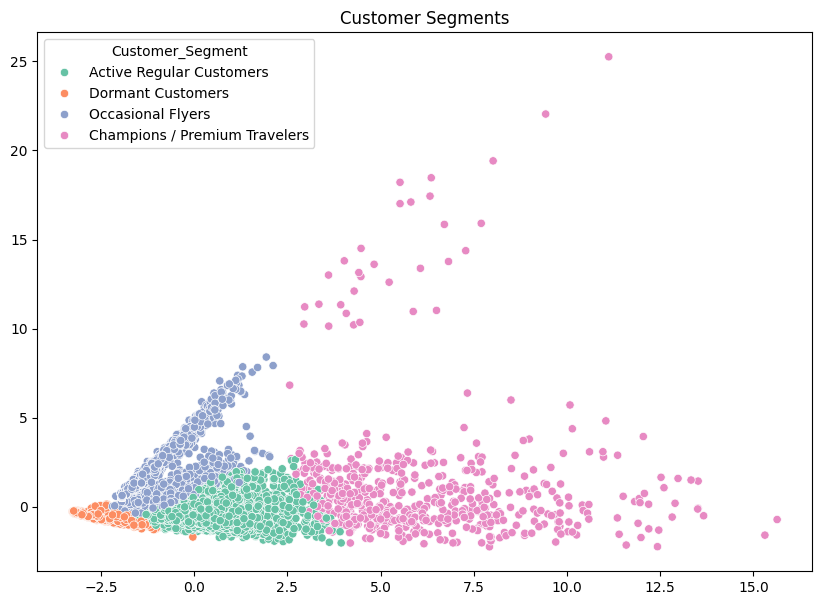

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=data_main['Customer_Segment'],
    palette='Set2'
)

plt.title('Customer Segments')
plt.show()

# Model Implementation

In [ ]:
features= [
    'CLV',
    'Total_Bookings',
    'Average_distance',
    'Recency_Months',
    'Booking_Trend',
    'Accumulation_Trend',
    'Redemption_Trend',
    'Seasonality_Index',
]

X = data_main[features]

y = data_main['Hard_Churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, pred in models.items():

    print(name)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))

    print("-"*40)

Logistic Regression
Accuracy : 0.9163679808841099
Precision: 0.841025641025641
Recall   : 0.39709443099273606
F1 Score : 0.5394736842105263
----------------------------------------
Random Forest
Accuracy : 0.9280167264038232
Precision: 0.7275132275132276
Recall   : 0.6658595641646489
F1 Score : 0.695322376738306
----------------------------------------
XGBoost
Accuracy : 0.9313022700119474
Precision: 0.6863543788187373
Recall   : 0.8159806295399515
F1 Score : 0.745575221238938
----------------------------------------


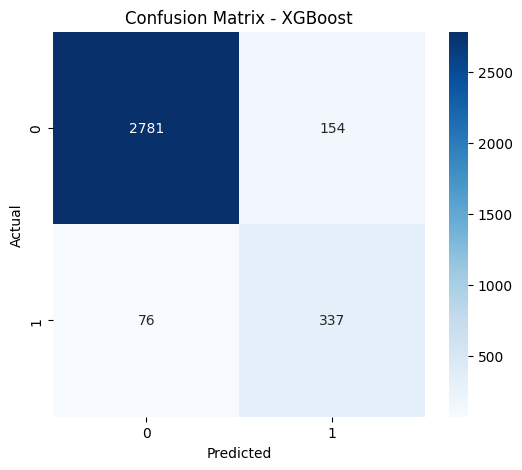

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9633706085442868


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print(feature_importance)

              Feature  Importance
1      Total_Bookings    0.449591
4       Booking_Trend    0.223772
3      Recency_Months    0.202904
5  Accumulation_Trend    0.050523
2    Average_distance    0.027683
7   Seasonality_Index    0.018280
6    Redemption_Trend    0.014030
0                 CLV    0.013218


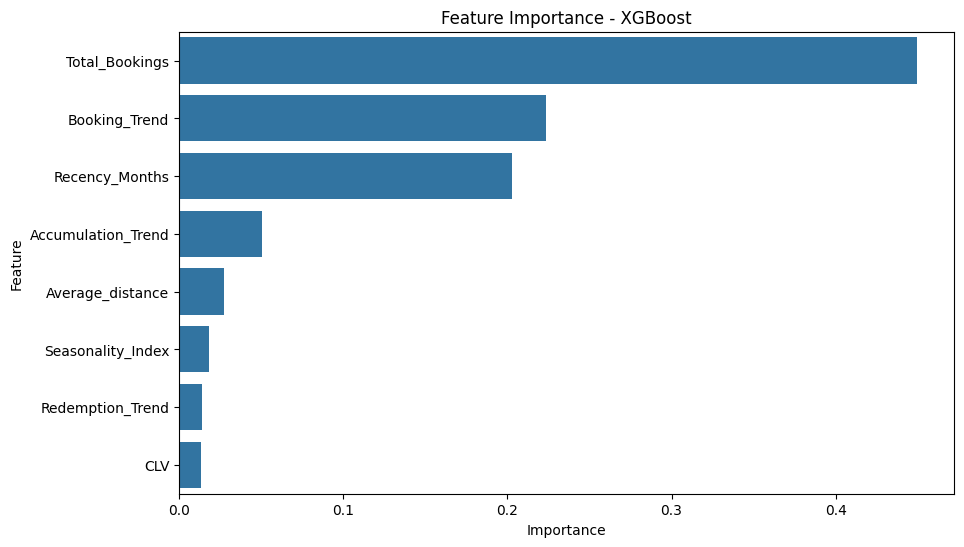

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - XGBoost")

plt.show()

In [ ]:
# Churn probabilities
y_prob = xgb.predict_proba(X_test)[:,1]

In [ ]:
retention_df = X_test.copy()

retention_df['Actual_Churn'] = y_test.values
retention_df['Churn_Probability'] = y_prob

retention_df.head()

,CLV,Total_Bookings,Average_distance,Recency_Months,Booking_Trend,Accumulation_Trend,Redemption_Trend,Seasonality_Index,Actual_Churn,Churn_Probability
2710,8672.19,24,1734.916667,0.0,-0.307692,-0.37,-0.95,8.67,0,0.002830
790,5013.14,29,1596.416667,8.0,-0.617021,-1.00,-0.98,14.25,0,0.860524
16412,21172.39,54,3282.125000,0.0,0.254545,0.76,-0.99,5.67,0,0.002983
9403,17771.55,3,229.916667,0.0,0.500000,919.67,0.00,0.92,0,0.002314
11793,2734.51,37,2618.625000,2.0,0.463415,1.54,-0.99,22.92,0,0.017421


In [ ]:
def assign_risk(prob):

    if prob >= 0.80:
        return 'High Risk'

    elif prob >= 0.40:
        return 'Medium Risk'

    else:
        return 'Low Risk'

retention_df['Risk_Level'] = (
    retention_df['Churn_Probability']
    .apply(assign_risk)
)

In [ ]:
data_main['Customer_Segment']

retention_df['Customer_Segment'] = (
    data_main.loc[X_test.index, 'Customer_Segment']
)

In [ ]:
def retention_action(row):

    risk = row['Risk_Level']
    segment = row['Customer_Segment']

    # High-risk customers
    if risk == 'High Risk':

        if segment == 'Dormant Customers':
            return "30% bonus miles + reactivation email"

        elif segment == 'Active Regular Customers':
            return "Personalized route discount"

        elif segment == 'Occasional Flyers':
            return "Weekend fare promotion"

        else:
            return "Premium retention package"

    # Medium-risk customers
    elif risk == 'Medium Risk':

        if segment == 'Champions / Premium Travelers':
            return "VIP upgrade and lounge voucher"

        else:
            return "Double miles campaign"

    # Low-risk customers
    else:

        if segment == 'Champions / Premium Travelers':
            return "Exclusive loyalty rewards"

        else:
            return "No immediate action"

retention_df['Recommended_Action'] = (
    retention_df.apply(retention_action, axis=1)
)

In [ ]:
high_risk_customers = (
    retention_df
    .sort_values(
        by='Churn_Probability',
        ascending=False
    )
)

high_risk_customers[
    [
        'Churn_Probability',
        'Risk_Level',
        'Customer_Segment',
        'Recommended_Action'
    ]
].head(20)

,Churn_Probability,Risk_Level,Customer_Segment,Recommended_Action
9659,0.983518,High Risk,Dormant Customers,30% bonus miles + reactivation email
9157,0.981656,High Risk,Dormant Customers,30% bonus miles + reactivation email
10078,0.981125,High Risk,Dormant Customers,30% bonus miles + reactivation email
16054,0.980301,High Risk,Dormant Customers,30% bonus miles + reactivation email
6299,0.979519,High Risk,Dormant Customers,30% bonus miles + reactivation email
16094,0.979119,High Risk,Dormant Customers,30% bonus miles + reactivation email
16400,0.978449,High Risk,Dormant Customers,30% bonus miles + reactivation email
7549,0.976856,High Risk,Dormant Customers,30% bonus miles + reactivation email
9590,0.975521,High Risk,Dormant Customers,30% bonus miles + reactivation email
3499,0.975335,High Risk,Dormant Customers,30% bonus miles + reactivation email


In [ ]:
risk_summary = (
    retention_df['Risk_Level']
    .value_counts()
    .reset_index()
)

risk_summary.columns = ['Risk_Level', 'Customers']

print(risk_summary)

    Risk_Level  Customers
0     Low Risk       2826
1  Medium Risk        372
2    High Risk        150


In [ ]:
action_summary = (
    retention_df['Recommended_Action']
    .value_counts()
    .reset_index()
)

action_summary.columns = ['Action', 'Customers']

print(action_summary)

                                 Action  Customers
0                   No immediate action       2708
1                 Double miles campaign        365
2  30% bonus miles + reactivation email        134
3             Exclusive loyalty rewards        118
4                Weekend fare promotion          9
5           Personalized route discount          7
6        VIP upgrade and lounge voucher          7


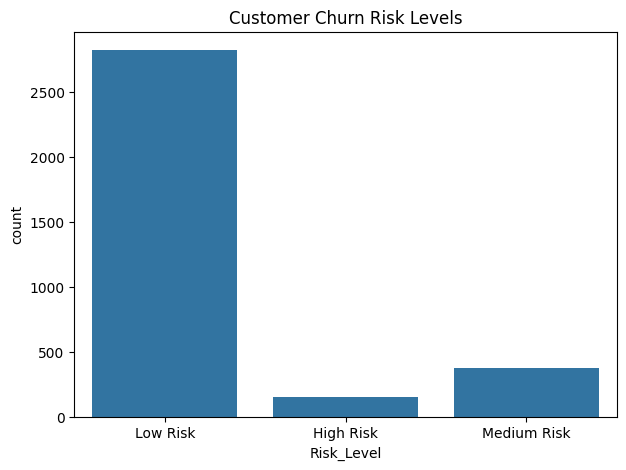

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.countplot(
    data=retention_df,
    x='Risk_Level'
)

plt.title("Customer Churn Risk Levels")
plt.show()

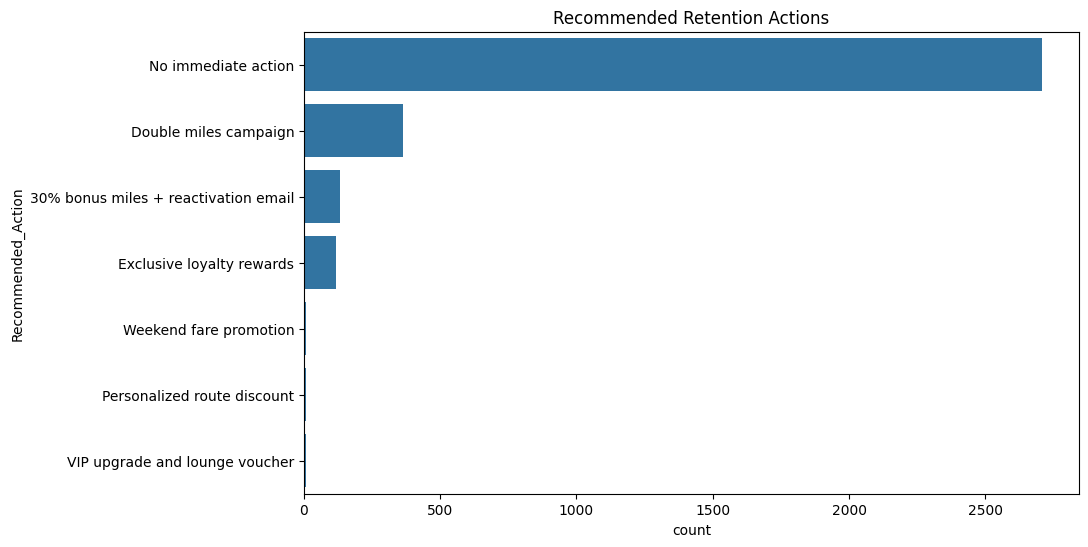

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=retention_df,
    y='Recommended_Action',
    order=retention_df['Recommended_Action'].value_counts().index
)

plt.title("Recommended Retention Actions")
plt.show()

In [ ]:
import joblib

# Save model
joblib.dump(xgb, "xgb_model.pkl")

# Save dashboard tables
retention_df.to_csv("retention_dashboard.csv", index=False)

feature_importance.to_csv("feature_importance.csv", index=False)

segment_behavior.to_csv("segment_behavior.csv")

data_main.to_csv("data_main.csv", index=False)